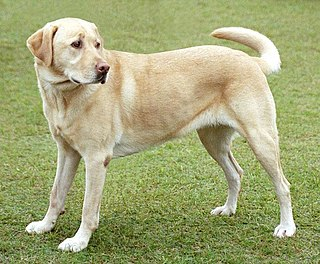

In [1]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch

# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
display(image)

## Random Rotation

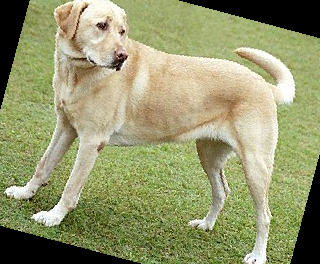

In [10]:
transform = transforms.RandomRotation(degrees=45)
rotated_image = transform(image)
display(rotated_image)

## Horizontal Flip

<p style="color:red; display:inline;"><strong>p</strong></p> is the probability that the image will be flipped horizontally.

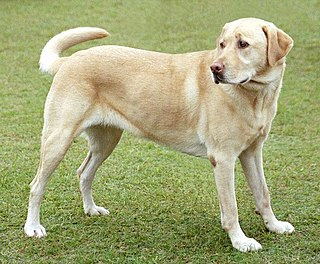

In [17]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.RandomHorizontalFlip(p=1)
flipped_image = transform(image)
display(flipped_image)



## Vertical Flip

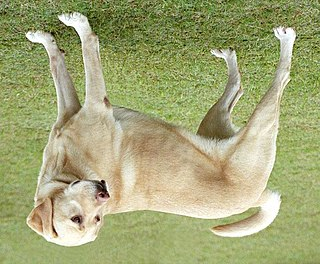

In [18]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.RandomVerticalFlip(p=1.0)
flipped_image = transform(image)
display(flipped_image)



## Color Jitter (brightness, contrast, saturation, hue)

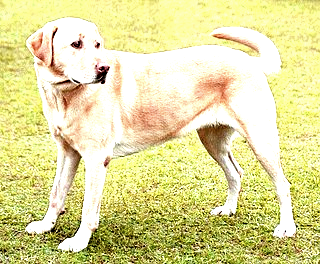

In [21]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.ColorJitter(
    brightness=(0.5, 1.5),   # Brightness factor ∈ [0.5, 1.5]
    contrast=(0.6, 1.4),     # Contrast factor ∈ [0.6, 1.4]
    saturation=(0.5, 1.5),   # Saturation factor ∈ [0.5, 1.5]
    hue=(-0.1, 0.1)          # Hue shift ∈ [-0.1, 0.1]
)
jittered_image = transform(image)
display(jittered_image)

- **Brightness** refers to how light or dark an image appears.  
- **Contrast** is the difference between light and dark areas.  
- **Saturation** describes the intensity or purity of colors.  
- **Hue** is the base color tone, represented as an angle on a color wheel (red, green, blue, etc.).


## Gaussian Blur

- Small kernel (e.g., **3×3**) → slight blur  
- Large kernel (e.g., **15×15**) → stronger blur, more smoothing


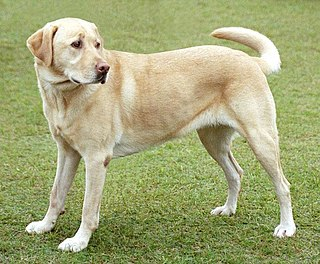

In [27]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.GaussianBlur(kernel_size=3)
blurred_image = transform(image)
display(blurred_image)

## Random Crop (with resize back)

- Randomly crops a **100×100** pixel square from the image.  
- Resizes the cropped image back to the **original image size**.

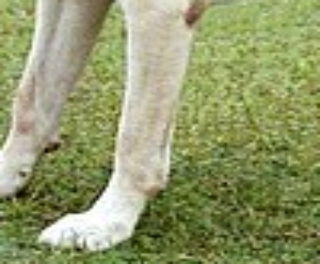

In [50]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.Compose([
    transforms.RandomCrop(100),
    transforms.Resize((image.height, image.width))
])
cropped_image = transform(image)
display(cropped_image)

## Center Crop

- This crops a **100×100** pixel square from the **center** of the image.  
- Unlike `RandomCrop`, this crop is **not random** — it’s always taken from the image’s center.


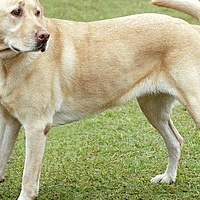

In [34]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.CenterCrop(200)
center_cropped = transform(image)
display(center_cropped)

## Random Affine Transformation (rotate, translate, scale, shear)

- `transforms.RandomAffine` adds **geometric distortion** to the image.


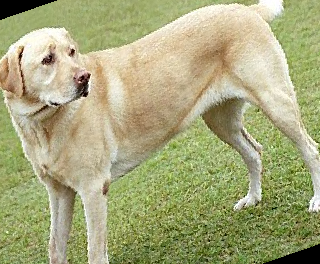

In [39]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.RandomAffine(
    degrees=30,              # Rotate randomly within [-30°, +30°]
    #translate=(0.1, 0.1),    # Shift image up to 10% of width and height|
    scale=(0.8, 1.2),        # Zoom in/out with scale factor between 0.8× and 1.2×
    shear=30                 # Shear by up to ±10° (slanting effect)
)
affine_image = transform(image)
display(affine_image)

## Elastic Transform 

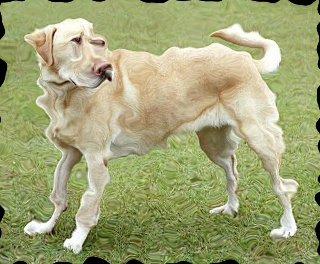

In [42]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.ElasticTransform(alpha=150.0)
elastic_image = transform(image)
display(elastic_image)

## Random Erasing (apply on tensor, so image must be tensor first)

This randomly erases (masks out) a rectangular region of the image, replacing the pixels with random values.

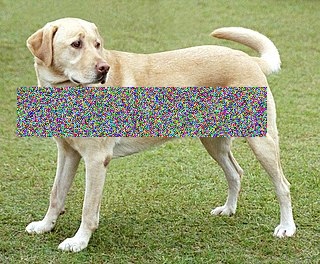

In [43]:
# Load grayscale image
image_path = "dog.jpg"
image = Image.open(image_path)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomErasing(p=1.0, scale=(0.1, 0.3), ratio=(0.2, 0.2), value='random')
])
tensor_image = transform(image)
erased_image = transforms.ToPILImage()(tensor_image)
display(erased_image)

## Mixup

- To improve **model generalization**, **robustness**, and **resistance to overfitting** by making the model learn **smooth decision boundaries** instead of memorizing **hard class boundaries**.


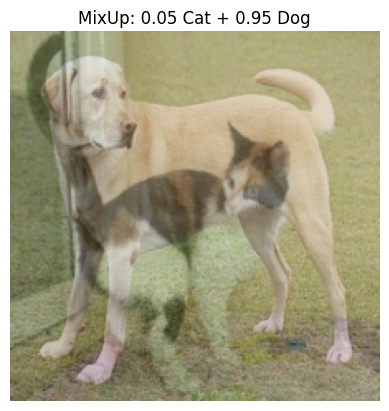

In [46]:
# 1. Load both images and convert to tensor
import numpy as np
cat_img = Image.open("cat.jpg").convert("RGB")
dog_img = Image.open("dog.jpg").convert("RGB")

# 2. Resize and convert to tensor
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

cat_tensor = transform(cat_img)
dog_tensor = transform(dog_img)

# 3. Sample mixup ratio (lambda) from Beta distribution
lam = np.random.beta(0.4, 0.4)

# 4. Perform MixUp
mixed_tensor = 0.5 * cat_tensor + (1 - 0.5) * dog_tensor

# 5. Display the mixed image
def imshow(img_tensor, title=""):
    img = img_tensor.numpy().transpose(1, 2, 0)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(title)
    plt.axis("off")
    plt.show()

imshow(mixed_tensor, title=f"MixUp: {lam:.2f} Cat + {(1-lam):.2f} Dog")

## Let's do some transformations on CIFAR-100

In [51]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [52]:
# Load CIFAR-100 class labels
cifar100_labels = torchvision.datasets.CIFAR100(root='./data', train=True, download=True).classes

# Define original and augmented transforms
transform_original = transforms.ToTensor()

transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.05, 0.2), ratio=(0.3, 3.3), value='random')
])

In [53]:
# Load datasets with different transforms
original_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, transform=transform_original)
augmented_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, transform=transform_augmented)


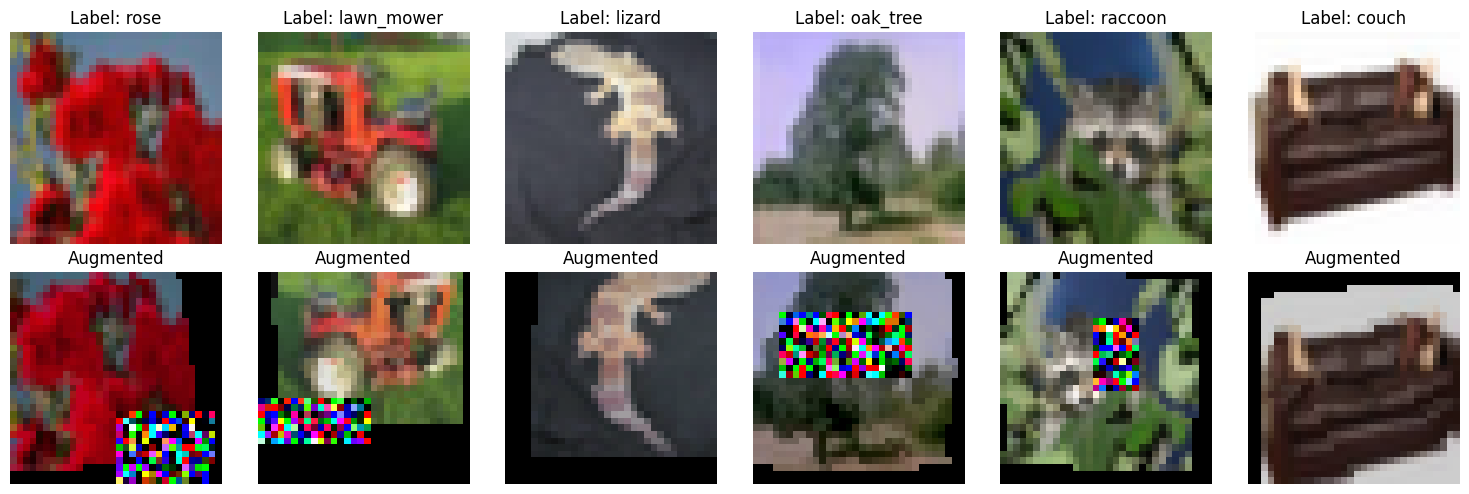

In [54]:
# Sample 6 random indices
indices = torch.randperm(len(original_dataset))[:6]
original_images = [original_dataset[i][0] for i in indices]
augmented_images = [augmented_dataset[i][0] for i in indices]
labels = [original_dataset[i][1] for i in indices]

# Function to show tensor image
def imshow(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1)
    return img

# Plot original (top) and augmented (bottom)
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(imshow(original_images[i]))
    axes[0, i].set_title(f"Label: {cifar100_labels[labels[i]]}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(imshow(augmented_images[i]))
    axes[1, i].set_title("Augmented")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## See the slides

### Let's see how CNN sees same images in different epochs

- We fixed the images only for visualization.
- This lets us observe how the **same images** look differently in each epoch due to random augmentations.
- Without fixing, we’d get new random images every time, making comparisons meaningless.

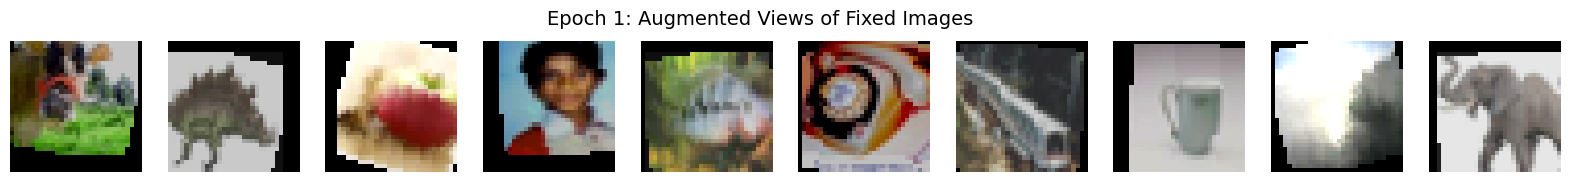

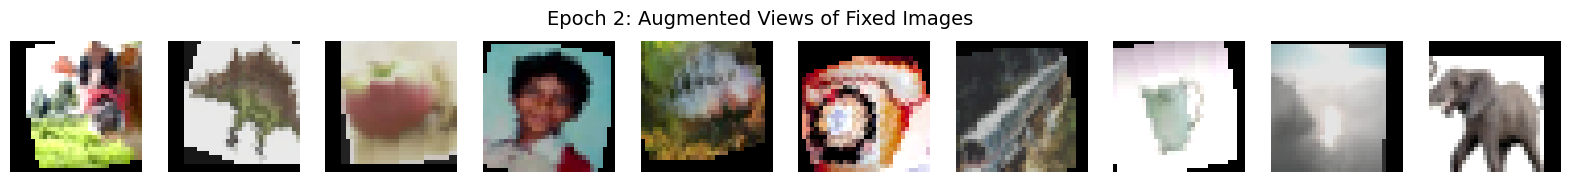

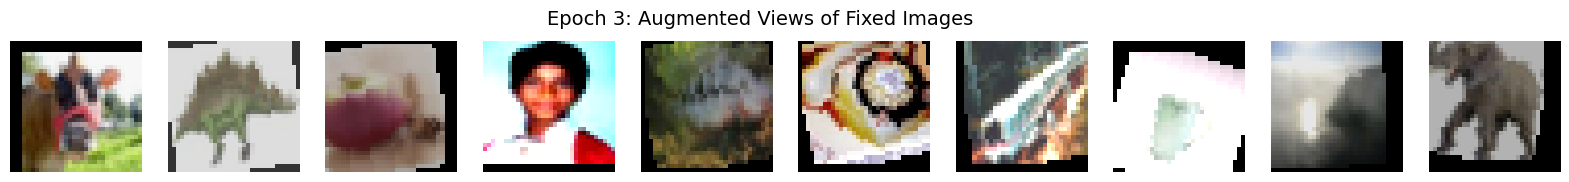

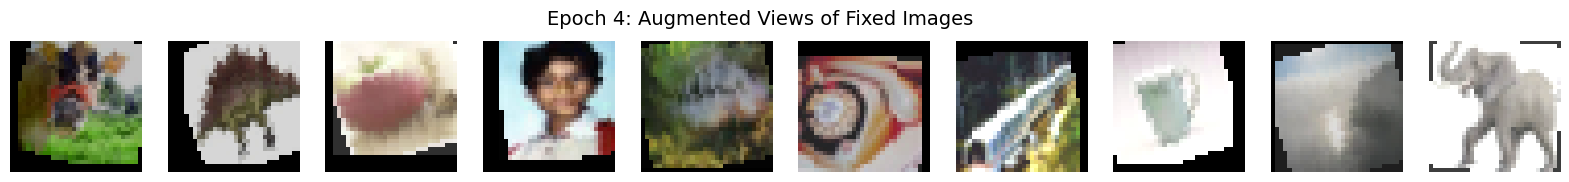

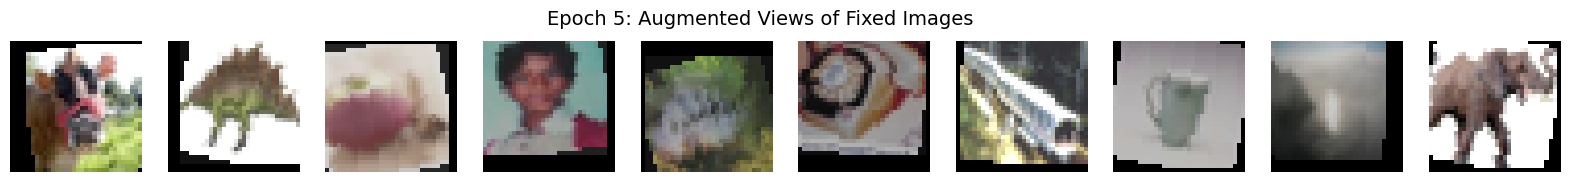

In [55]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Augmentation transform
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])

# 2. CIFAR-100 dataset with augmentations
train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# 3. Simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 256),
            nn.ReLU(),
            nn.Linear(256, 100)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

# 4. Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Fixed images to visualize each epoch
raw_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, transform=transforms.ToTensor())
fixed_images, _ = next(iter(torch.utils.data.DataLoader(raw_dataset, batch_size=10, shuffle=False)))
fixed_images = [img for img in fixed_images]

# 6. Training loop with visualization
for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Visualize how fixed images look after transform in this epoch
    augmented = [train_transform(transforms.ToPILImage()(img)) for img in fixed_images]
    fig, axes = plt.subplots(1, 10, figsize=(20, 2))
    for i, img in enumerate(augmented):
        img_np = img.numpy().transpose((1, 2, 0))
        axes[i].imshow(np.clip(img_np, 0, 1))
        axes[i].axis('off')
    plt.suptitle(f"Epoch {epoch+1}: Augmented Views of Fixed Images", fontsize=14)
    plt.show()
